# Proyecto Módulo 4 - Análisis Exploratorio de Datos para Decisiones Comerciales
## Lección 1 - Generación del dataset e inspección inicial

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================
SEED = 13094978
np.random.seed(SEED)

N_CLIENTES = 750
RUTA_DATASET_RAW = "../data/raw/comercioya_clientes_raw.csv"

# Crear carpeta si no existe
Path("../data/raw").mkdir(parents=True, exist_ok=True)

# =========================================================
# 1) GENERACIÓN DEL DATASET
# =========================================================
id_cliente = np.arange(1001, 1001 + N_CLIENTES)

segmento_cliente = np.random.choice(
    ["Bronce", "Plata", "Oro", "Premium"],
    size=N_CLIENTES,
    p=[0.35, 0.30, 0.22, 0.13]
).astype(object)

ciudad = np.random.choice(
    ["Santiago", "Valparaíso", "Concepción", "La Serena", "Antofagasta", "Temuco", "Rancagua", "Puerto Montt"],
    size=N_CLIENTES
).astype(object)

canal_adquisicion = np.random.choice(
    ["Orgánico", "Google Ads", "Instagram", "Email", "Referido"],
    size=N_CLIENTES,
    p=[0.25, 0.25, 0.20, 0.15, 0.15]
).astype(object)

cliente_premium = np.random.choice(
    ["Sí", "No"],
    size=N_CLIENTES,
    p=[0.22, 0.78]
).astype(object)

uso_cupon = np.random.choice(
    ["Sí", "No"],
    size=N_CLIENTES,
    p=[0.38, 0.62]
).astype(object)

edad = np.random.randint(18, 71, size=N_CLIENTES)

# Variables auxiliares numéricas para dar lógica al dataset
mapa_segmento = {"Bronce": 0, "Plata": 1, "Oro": 2, "Premium": 3}
segmento_num = pd.Series(segmento_cliente).map(mapa_segmento).values
premium_num = np.where(cliente_premium == "Sí", 1, 0)
cupon_num = np.where(uso_cupon == "Sí", 1, 0)

visitas_sitio = np.round(
    np.random.normal(18 + 6 * segmento_num + 8 * premium_num, 6, N_CLIENTES)
).astype(int)
visitas_sitio = np.clip(visitas_sitio, 1, None)

tiempo_sitio_min = np.round(
    np.random.normal(5 + 0.45 * visitas_sitio + 2 * premium_num, 5, N_CLIENTES),
    2
)
tiempo_sitio_min = np.clip(tiempo_sitio_min, 1, None)

compras_realizadas = np.round(
    0.12 * visitas_sitio + 0.14 * tiempo_sitio_min + 0.8 * premium_num + np.random.normal(0, 1.8, N_CLIENTES)
).astype(int)
compras_realizadas = np.clip(compras_realizadas, 0, None)

ticket_promedio = np.round(
    np.random.normal(18000 + 9000 * segmento_num + 14000 * premium_num + 2500 * cupon_num, 7000, N_CLIENTES),
    2
)
ticket_promedio = np.clip(ticket_promedio, 4000, None)

monto_total = np.round(
    compras_realizadas * ticket_promedio + np.random.normal(0, 12000, N_CLIENTES),
    2
)
monto_total = np.clip(monto_total, 0, None)

prob_devolucion = np.clip(0.10 - 0.015 * premium_num + 0.01 * cupon_num, 0.02, 0.18)
devoluciones = np.random.binomial(compras_realizadas, prob_devolucion)

dias_desde_ultima_compra = np.round(
    np.random.normal(65 - 4 * compras_realizadas - 6 * segmento_num - 10 * premium_num, 18, N_CLIENTES)
).astype(int)
dias_desde_ultima_compra = np.clip(dias_desde_ultima_compra, 0, 365)

resena_score = np.round(
    np.random.normal(4.4 - 0.18 * devoluciones - 0.012 * dias_desde_ultima_compra + 0.18 * premium_num, 0.45, N_CLIENTES),
    1
)
resena_score = np.clip(resena_score, 1, 5)

tasa_conversion = np.round(
    np.where(visitas_sitio > 0, compras_realizadas / visitas_sitio, 0),
    3
)

# =========================================================
# 2) INTRODUCCIÓN INTENCIONAL DE NULOS, INCONSISTENCIAS Y OUTLIERS
# =========================================================
# Nulos
idx_nulos_ciudad = np.random.choice(N_CLIENTES, size=12, replace=False)
idx_nulos_tiempo = np.random.choice(N_CLIENTES, size=10, replace=False)
idx_nulos_resena = np.random.choice(N_CLIENTES, size=14, replace=False)

for i in idx_nulos_ciudad:
    ciudad[i] = None

tiempo_sitio_min[idx_nulos_tiempo] = np.nan
resena_score[idx_nulos_resena] = np.nan

# Inconsistencias categóricas
idx_segmento_inconsistente = np.random.choice(N_CLIENTES, size=9, replace=False)
segmento_cliente[idx_segmento_inconsistente[:3]] = "premium"
segmento_cliente[idx_segmento_inconsistente[3:6]] = "ORO"
segmento_cliente[idx_segmento_inconsistente[6:]] = "plata "

idx_ciudad_inconsistente = np.random.choice(N_CLIENTES, size=9, replace=False)
ciudad[idx_ciudad_inconsistente[:3]] = "santiago"
ciudad[idx_ciudad_inconsistente[3:6]] = "Valparaíso "
ciudad[idx_ciudad_inconsistente[6:]] = "CONCEPCIÓN"

idx_canal_inconsistente = np.random.choice(N_CLIENTES, size=6, replace=False)
canal_adquisicion[idx_canal_inconsistente[:2]] = "google ads"
canal_adquisicion[idx_canal_inconsistente[2:4]] = "EMAIL "
canal_adquisicion[idx_canal_inconsistente[4:]] = "organico"

# Outliers razonables
idx_outliers = np.random.choice(N_CLIENTES, size=8, replace=False)
visitas_sitio[idx_outliers] = visitas_sitio[idx_outliers] * 4
tiempo_sitio_min[idx_outliers] = np.round(tiempo_sitio_min[idx_outliers] * 2.5, 2)
monto_total[idx_outliers] = np.round(monto_total[idx_outliers] * 4.5, 2)

# =========================================================
# 3) CREACIÓN DEL DATAFRAME
# =========================================================
df = pd.DataFrame({
    "id_cliente": id_cliente,
    "edad": edad,
    "segmento_cliente": segmento_cliente,
    "ciudad": ciudad,
    "canal_adquisicion": canal_adquisicion,
    "cliente_premium": cliente_premium,
    "uso_cupon": uso_cupon,
    "visitas_sitio": visitas_sitio,
    "tiempo_sitio_min": tiempo_sitio_min,
    "compras_realizadas": compras_realizadas,
    "ticket_promedio": ticket_promedio,
    "monto_total": monto_total,
    "devoluciones": devoluciones,
    "resena_score": resena_score,
    "dias_desde_ultima_compra": dias_desde_ultima_compra,
    "tasa_conversion": tasa_conversion
})

# Guardar dataset raw
df.to_csv(RUTA_DATASET_RAW, index=False)

# =========================================================
# 4) INSPECCIÓN INICIAL DEL DATASET
# =========================================================
print("===== PRIMERAS 5 FILAS =====")
display(df.head())

print("===== ÚLTIMAS 5 FILAS =====")
display(df.tail())

print("===== DIMENSIONES =====")
print(df.shape)

print("\n===== TIPOS DE DATOS =====")
display(df.dtypes.to_frame("tipo_dato"))

print("\n===== VALORES FALTANTES =====")
display(df.isna().sum().to_frame("nulos").sort_values(by="nulos", ascending=False))

# =========================================================
# 5) CLASIFICACIÓN DE VARIABLES
# =========================================================
variables_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_categoricas = df.select_dtypes(include=["object"]).columns.tolist()

resumen_variables = pd.DataFrame({
    "tipo_variable": ["Numérica"] * len(variables_numericas) + ["Categórica"] * len(variables_categoricas),
    "nombre_variable": variables_numericas + variables_categoricas
})

print("\n===== CLASIFICACIÓN DE VARIABLES =====")
display(resumen_variables)

# =========================================================
# 6) REVISIÓN RÁPIDA DE INCONSISTENCIAS
# =========================================================
print("\n===== VALORES ÚNICOS EN SEGMENTO_CLIENTE =====")
display(pd.Series(df["segmento_cliente"].unique(), name="segmento_cliente"))

print("\n===== VALORES ÚNICOS EN CIUDAD =====")
display(pd.Series(df["ciudad"].dropna().unique(), name="ciudad"))

print("\n===== VALORES ÚNICOS EN CANAL_ADQUISICION =====")
display(pd.Series(df["canal_adquisicion"].unique(), name="canal_adquisicion"))

# =========================================================
# 7) RESUMEN INICIAL DE HALLAZGOS
# =========================================================
print("\n===== HALLAZGOS INICIALES =====")
print(f"Total de registros: {df.shape[0]}")
print(f"Total de columnas: {df.shape[1]}")
print(f"Variables numéricas: {len(variables_numericas)}")
print(f"Variables categóricas: {len(variables_categoricas)}")
print(f"Nulos en ciudad: {df['ciudad'].isna().sum()}")
print(f"Nulos en tiempo_sitio_min: {df['tiempo_sitio_min'].isna().sum()}")
print(f"Nulos en resena_score: {df['resena_score'].isna().sum()}")
print(f"Monto total máximo: {df['monto_total'].max():,.2f}")
print(f"Visitas máximas al sitio: {df['visitas_sitio'].max()}")
print(f"Archivo guardado en: {RUTA_DATASET_RAW}")

===== PRIMERAS 5 FILAS =====


,id_cliente,edad,segmento_cliente,ciudad,canal_adquisicion,cliente_premium,uso_cupon,visitas_sitio,tiempo_sitio_min,compras_realizadas,ticket_promedio,monto_total,devoluciones,resena_score,dias_desde_ultima_compra,tasa_conversion
0,1001,46,Plata,La Serena,Instagram,Sí,No,29,20.65,5,35281.08,185050.97,1,5.0,0,0.172
1,1002,33,Bronce,La Serena,Email,No,No,10,15.35,3,18309.71,55866.28,0,NaN,41,0.300
2,1003,38,Plata,Santiago,Google Ads,No,No,26,15.55,6,28472.79,193027.78,1,4.0,54,0.231
3,1004,67,Bronce,Puerto Montt,Instagram,No,Sí,24,12.00,5,18233.65,79332.66,2,4.0,46,0.208
4,1005,52,Premium,Rancagua,Orgánico,No,Sí,31,17.56,8,50541.62,413849.80,1,4.4,16,0.258


===== ÚLTIMAS 5 FILAS =====


,id_cliente,edad,segmento_cliente,ciudad,canal_adquisicion,cliente_premium,uso_cupon,visitas_sitio,tiempo_sitio_min,compras_realizadas,ticket_promedio,monto_total,devoluciones,resena_score,dias_desde_ultima_compra,tasa_conversion
745,1746,48,Oro,Temuco,Instagram,Sí,Sí,38,34.21,10,46313.13,459191.59,0,4.5,1,0.263
746,1747,54,Bronce,Santiago,Instagram,No,Sí,17,18.78,5,24126.58,114085.88,0,4.7,18,0.294
747,1748,60,Bronce,La Serena,Orgánico,No,No,23,22.64,8,9547.34,69673.37,1,3.7,32,0.348
748,1749,42,Premium,Puerto Montt,Google Ads,No,Sí,34,9.87,4,49087.55,192827.89,0,4.6,37,0.118
749,1750,51,Plata,Antofagasta,Instagram,No,Sí,24,17.75,2,31517.41,63193.58,0,3.8,28,0.083


===== DIMENSIONES =====
(750, 16)

===== TIPOS DE DATOS =====


...


===== VALORES ÚNICOS EN CIUDAD =====


0        La Serena
1         Santiago
2     Puerto Montt
3         Rancagua
4      Antofagasta
5       Valparaíso
6       Concepción
7           Temuco
8       CONCEPCIÓN
9         santiago
10     Valparaíso 
Name: ciudad, dtype: object


===== VALORES ÚNICOS EN CANAL_ADQUISICION =====


0     Instagram
1         Email
2    Google Ads
3      Orgánico
4      Referido
5    google ads
6      organico
7        EMAIL 
Name: canal_adquisicion, dtype: object


===== HALLAZGOS INICIALES =====
Total de registros: 750
Total de columnas: 16
Variables numéricas: 5
Variables categóricas: 5
Nulos en ciudad: 12
Nulos en tiempo_sitio_min: 10
Nulos en resena_score: 14
Monto total máximo: 1,787,130.04
Visitas máximas al sitio: 136
Archivo guardado en: ../data/raw/comercioya_clientes_raw.csv


In [4]:
# =========================================================
# CORRECCIÓN DE CLASIFICACIÓN DE VARIABLES
# =========================================================
from pandas.api.types import is_numeric_dtype, is_string_dtype

variables_numericas = [col for col in df.columns if is_numeric_dtype(df[col])]
variables_categoricas = [col for col in df.columns if is_string_dtype(df[col]) or df[col].dtype == "object"]

resumen_variables = pd.DataFrame({
    "tipo_variable": ["Numérica"] * len(variables_numericas) + ["Categórica"] * len(variables_categoricas),
    "nombre_variable": variables_numericas + variables_categoricas
})

print("===== CLASIFICACIÓN CORREGIDA DE VARIABLES =====")
display(resumen_variables)

print(f"Total variables numéricas: {len(variables_numericas)}")
print(f"Total variables categóricas: {len(variables_categoricas)}")
print(f"Total variables clasificadas: {len(variables_numericas) + len(variables_categoricas)}")

===== CLASIFICACIÓN CORREGIDA DE VARIABLES =====


,tipo_variable,nombre_variable
0,Numérica,id_cliente
1,Numérica,edad
2,Numérica,visitas_sitio
3,Numérica,tiempo_sitio_min
4,Numérica,compras_realizadas
5,Numérica,ticket_promedio
6,Numérica,monto_total
7,Numérica,devoluciones
8,Numérica,resena_score
9,Numérica,dias_desde_ultima_compra


Total variables numéricas: 11
Total variables categóricas: 5
Total variables clasificadas: 16


## Lección 2 - Estadística descriptiva

===== DIMENSIONES DEL DATASET =====
(750, 16)

===== RESUMEN ESTADÍSTICO =====


,media,mediana,moda,varianza,desv_std,q1,q3,p10,p90
edad,44.805,46.000,41.0,2.179810e+02,14.764,33.000,57.000,23.000,65.000
visitas_sitio,27.567,27.000,28.0,1.458530e+02,12.077,20.000,33.000,15.000,39.000
tiempo_sitio_min,17.783,17.705,1.0,5.100000e+01,7.141,13.042,22.080,9.422,26.635
compras_realizadas,5.855,6.000,5.0,7.131000e+00,2.670,4.000,8.000,2.000,9.000
ticket_promedio,32206.149,32001.470,4000.0,1.748213e+08,13222.000,21928.247,41450.268,14952.523,50082.244
monto_total,210938.637,175455.535,0.0,2.729600e+10,165214.999,94697.370,285554.402,41541.869,427649.387
devoluciones,0.545,0.000,0.0,5.690000e-01,0.754,0.000,1.000,0.000,2.000
resena_score,3.934,3.950,3.8,2.880000e-01,0.537,3.600,4.300,3.250,4.600
dias_desde_ultima_compra,32.696,33.000,0.0,4.422890e+02,21.031,17.000,47.000,2.000,60.000
tasa_conversion,0.229,0.217,0.2,1.500000e-02,0.123,0.167,0.273,0.115,0.333



===== RESUMEN DE OUTLIERS (IQR) =====


,variable,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers
0,visitas_sitio,20.000,33.000,13.000,0.500,52.500,12
1,tiempo_sitio_min,13.042,22.080,9.037,-0.514,35.636,10
2,ticket_promedio,21928.247,41450.268,19522.020,-7354.783,70733.298,2
3,monto_total,94697.370,285554.402,190857.033,-191588.179,571839.951,22
4,devoluciones,0.000,1.000,1.000,-1.500,2.500,16


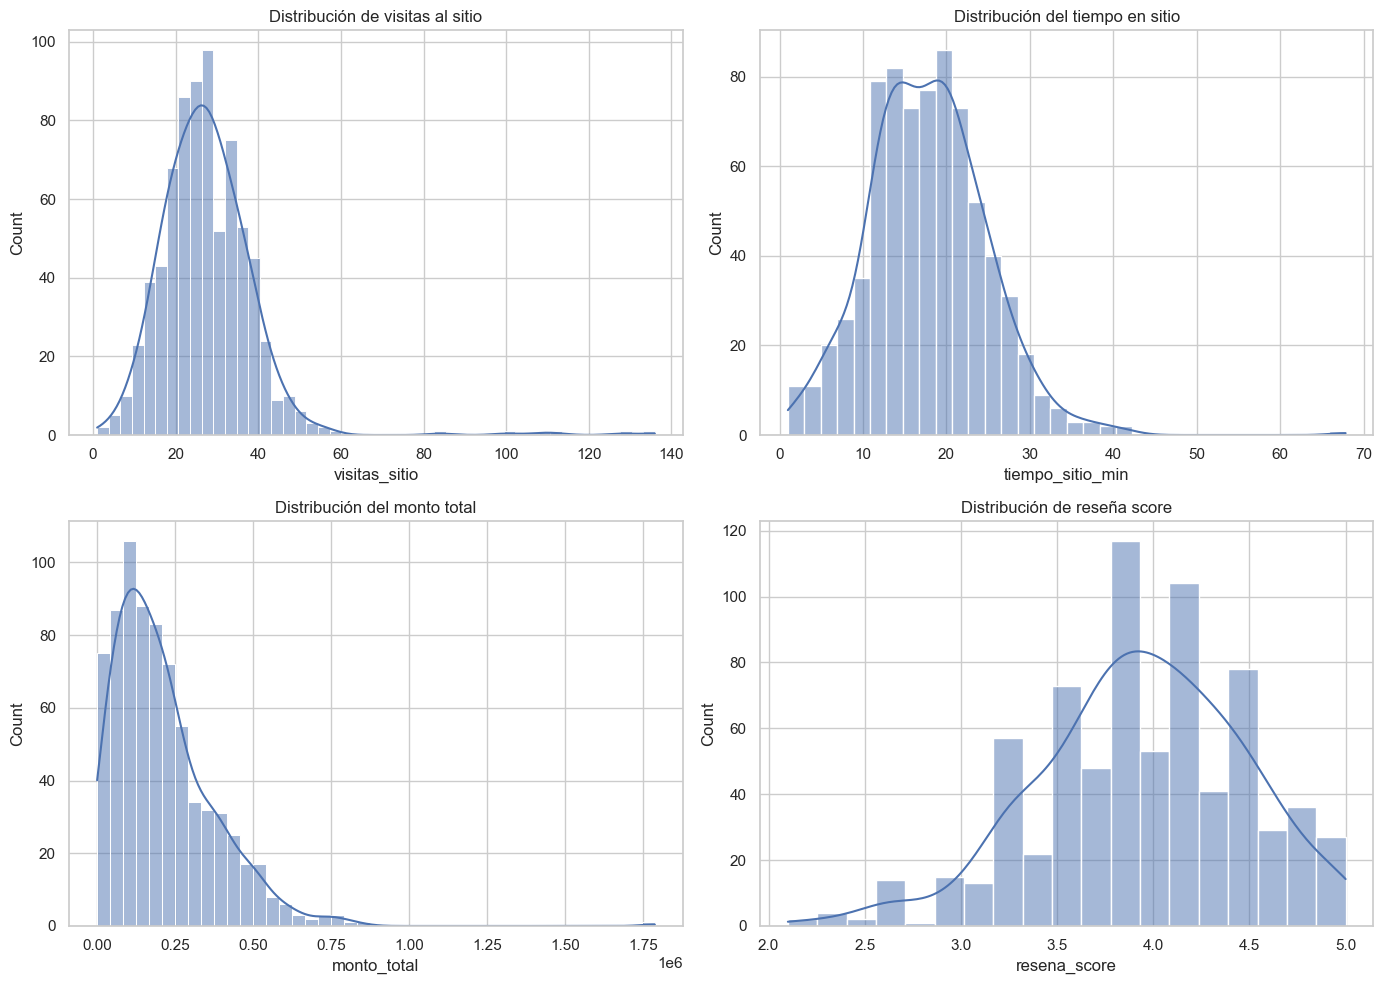

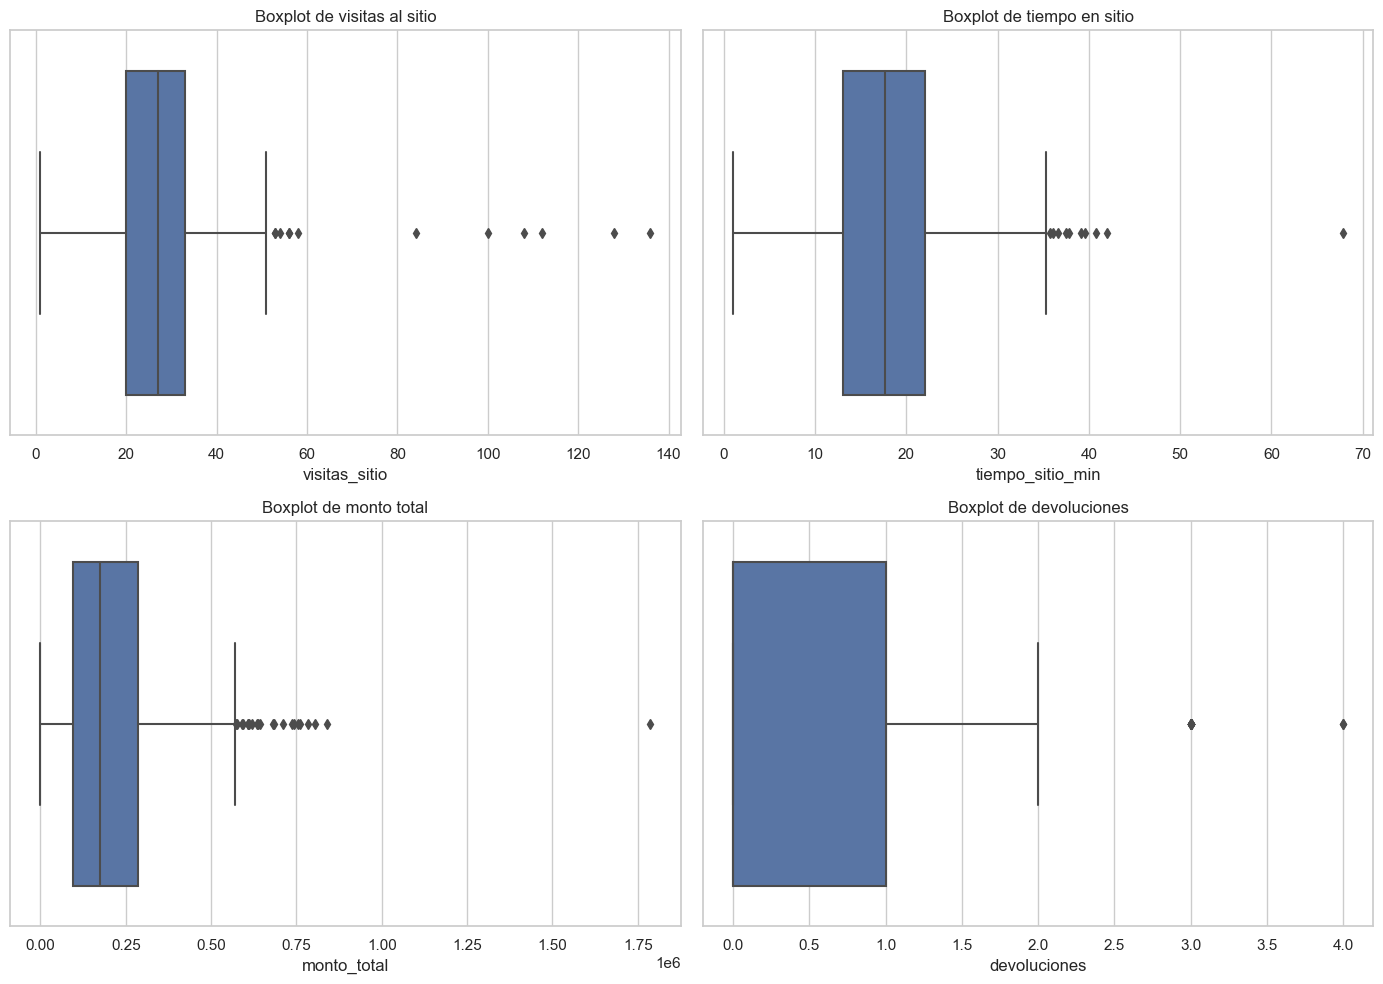


===== INTERPRETACIÓN INICIAL =====
La variable visitas_sitio presenta 12 posibles outliers según el criterio IQR.
La variable tiempo_sitio_min presenta 10 posibles outliers según el criterio IQR.
La variable ticket_promedio presenta 2 posibles outliers según el criterio IQR.
La variable monto_total presenta 22 posibles outliers según el criterio IQR.
La variable devoluciones presenta 16 posibles outliers según el criterio IQR.


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN VISUAL
# =========================================================
sns.set_theme(style="whitegrid")

# =========================================================
# CARGA DEL DATASET
# =========================================================
RUTA_DATASET_RAW = "../data/raw/comercioya_clientes_raw.csv"
df_eda = pd.read_csv(RUTA_DATASET_RAW)

print("===== DIMENSIONES DEL DATASET =====")
print(df_eda.shape)

# =========================================================
# 1) ESTADÍSTICA DESCRIPTIVA BÁSICA
# =========================================================
variables_numericas = [
    "edad",
    "visitas_sitio",
    "tiempo_sitio_min",
    "compras_realizadas",
    "ticket_promedio",
    "monto_total",
    "devoluciones",
    "resena_score",
    "dias_desde_ultima_compra",
    "tasa_conversion"
]

resumen_estadistico = pd.DataFrame(index=variables_numericas)

resumen_estadistico["media"] = df_eda[variables_numericas].mean()
resumen_estadistico["mediana"] = df_eda[variables_numericas].median()
resumen_estadistico["moda"] = df_eda[variables_numericas].mode().iloc[0]
resumen_estadistico["varianza"] = df_eda[variables_numericas].var()
resumen_estadistico["desv_std"] = df_eda[variables_numericas].std()
resumen_estadistico["q1"] = df_eda[variables_numericas].quantile(0.25)
resumen_estadistico["q3"] = df_eda[variables_numericas].quantile(0.75)
resumen_estadistico["p10"] = df_eda[variables_numericas].quantile(0.10)
resumen_estadistico["p90"] = df_eda[variables_numericas].quantile(0.90)

print("\n===== RESUMEN ESTADÍSTICO =====")
display(resumen_estadistico.round(3))

# =========================================================
# 2) DETECCIÓN DE OUTLIERS CON IQR
# =========================================================
def detectar_outliers_iqr(df, columna):
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    cantidad = df[(df[columna] < li) | (df[columna] > ls)][columna].count()
    return q1, q3, iqr, li, ls, cantidad

columnas_outliers = [
    "visitas_sitio",
    "tiempo_sitio_min",
    "ticket_promedio",
    "monto_total",
    "devoluciones"
]

resumen_outliers = []

for col in columnas_outliers:
    q1, q3, iqr, li, ls, cantidad = detectar_outliers_iqr(df_eda, col)
    resumen_outliers.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": li,
        "limite_superior": ls,
        "cantidad_outliers": cantidad
    })

df_outliers = pd.DataFrame(resumen_outliers)

print("\n===== RESUMEN DE OUTLIERS (IQR) =====")
display(df_outliers.round(3))

# =========================================================
# 3) HISTOGRAMAS
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_eda["visitas_sitio"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribución de visitas al sitio")

sns.histplot(df_eda["tiempo_sitio_min"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribución del tiempo en sitio")

sns.histplot(df_eda["monto_total"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribución del monto total")

sns.histplot(df_eda["resena_score"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Distribución de reseña score")

plt.tight_layout()
plt.show()

# =========================================================
# 4) BOXPLOTS
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x=df_eda["visitas_sitio"], ax=axes[0, 0])
axes[0, 0].set_title("Boxplot de visitas al sitio")

sns.boxplot(x=df_eda["tiempo_sitio_min"], ax=axes[0, 1])
axes[0, 1].set_title("Boxplot de tiempo en sitio")

sns.boxplot(x=df_eda["monto_total"], ax=axes[1, 0])
axes[1, 0].set_title("Boxplot de monto total")

sns.boxplot(x=df_eda["devoluciones"], ax=axes[1, 1])
axes[1, 1].set_title("Boxplot de devoluciones")

plt.tight_layout()
plt.show()

# =========================================================
# 5) INTERPRETACIÓN INICIAL DEL IMPACTO DE OUTLIERS
# =========================================================
print("\n===== INTERPRETACIÓN INICIAL =====")
for _, fila in df_outliers.iterrows():
    print(
        f"La variable {fila['variable']} presenta {int(fila['cantidad_outliers'])} posibles outliers "
        f"según el criterio IQR."
    )

### Hallazgos de estadística descriptiva

A partir del análisis descriptivo fue posible identificar la distribución general de las principales variables numéricas del dataset, así como sus medidas de tendencia central y dispersión. Los resultados muestran que variables como monto total, visitas al sitio y tiempo de permanencia presentan dispersión relevante y posibles asimetrías, lo que sugiere heterogeneidad en el comportamiento de los clientes. Asimismo, los boxplots permitieron detectar valores atípicos en variables comerciales clave, especialmente en monto total y visitas al sitio, lo que podría influir en promedios y decisiones analíticas posteriores. En consecuencia, estos hallazgos justifican profundizar en el estudio de correlaciones y relaciones entre variables en las siguientes etapas.

## Lección 3 - Correlación

===== DIMENSIONES DEL DATASET =====
(750, 16)

===== MATRIZ DE CORRELACIÓN DE PEARSON =====


,edad,visitas_sitio,tiempo_sitio_min,compras_realizadas,ticket_promedio,monto_total,devoluciones,resena_score,dias_desde_ultima_compra,tasa_conversion
edad,1.000,-0.035,-0.008,0.037,-0.002,0.016,0.008,0.068,-0.044,0.092
visitas_sitio,-0.035,1.000,0.712,0.499,0.482,0.703,0.196,0.189,-0.361,-0.189
tiempo_sitio_min,-0.008,0.712,1.000,0.635,0.444,0.690,0.204,0.195,-0.423,0.055
compras_realizadas,0.037,0.499,0.635,1.000,0.504,0.797,0.283,0.283,-0.595,0.374
ticket_promedio,-0.002,0.482,0.444,0.504,1.000,0.770,0.184,0.248,-0.441,-0.045
monto_total,0.016,0.703,0.690,0.797,0.770,1.000,0.288,0.261,-0.525,0.180
devoluciones,0.008,0.196,0.204,0.283,0.184,0.288,1.000,-0.140,-0.205,0.111
resena_score,0.068,0.189,0.195,0.283,0.248,0.261,-0.140,1.000,-0.448,0.040
dias_desde_ultima_compra,-0.044,-0.361,-0.423,-0.595,-0.441,-0.525,-0.205,-0.448,1.000,-0.109
tasa_conversion,0.092,-0.189,0.055,0.374,-0.045,0.180,0.111,0.040,-0.109,1.000



===== TOP 10 CORRELACIONES ABSOLUTAS =====


,variable_1,variable_2,pearson_r
35,compras_realizadas,monto_total,0.797
45,ticket_promedio,monto_total,0.770
12,visitas_sitio,tiempo_sitio_min,0.712
15,visitas_sitio,monto_total,0.703
25,tiempo_sitio_min,monto_total,0.690
23,tiempo_sitio_min,compras_realizadas,0.635
38,compras_realizadas,dias_desde_ultima_compra,-0.595
58,monto_total,dias_desde_ultima_compra,-0.525
34,compras_realizadas,ticket_promedio,0.504
13,visitas_sitio,compras_realizadas,0.499



===== COEFICIENTES PEARSON EN PARES CLAVE =====


,variable_1,variable_2,pearson_r
0,visitas_sitio,compras_realizadas,0.499
1,compras_realizadas,monto_total,0.797
2,ticket_promedio,monto_total,0.770
3,dias_desde_ultima_compra,resena_score,-0.448
4,devoluciones,resena_score,-0.140
5,visitas_sitio,tiempo_sitio_min,0.712


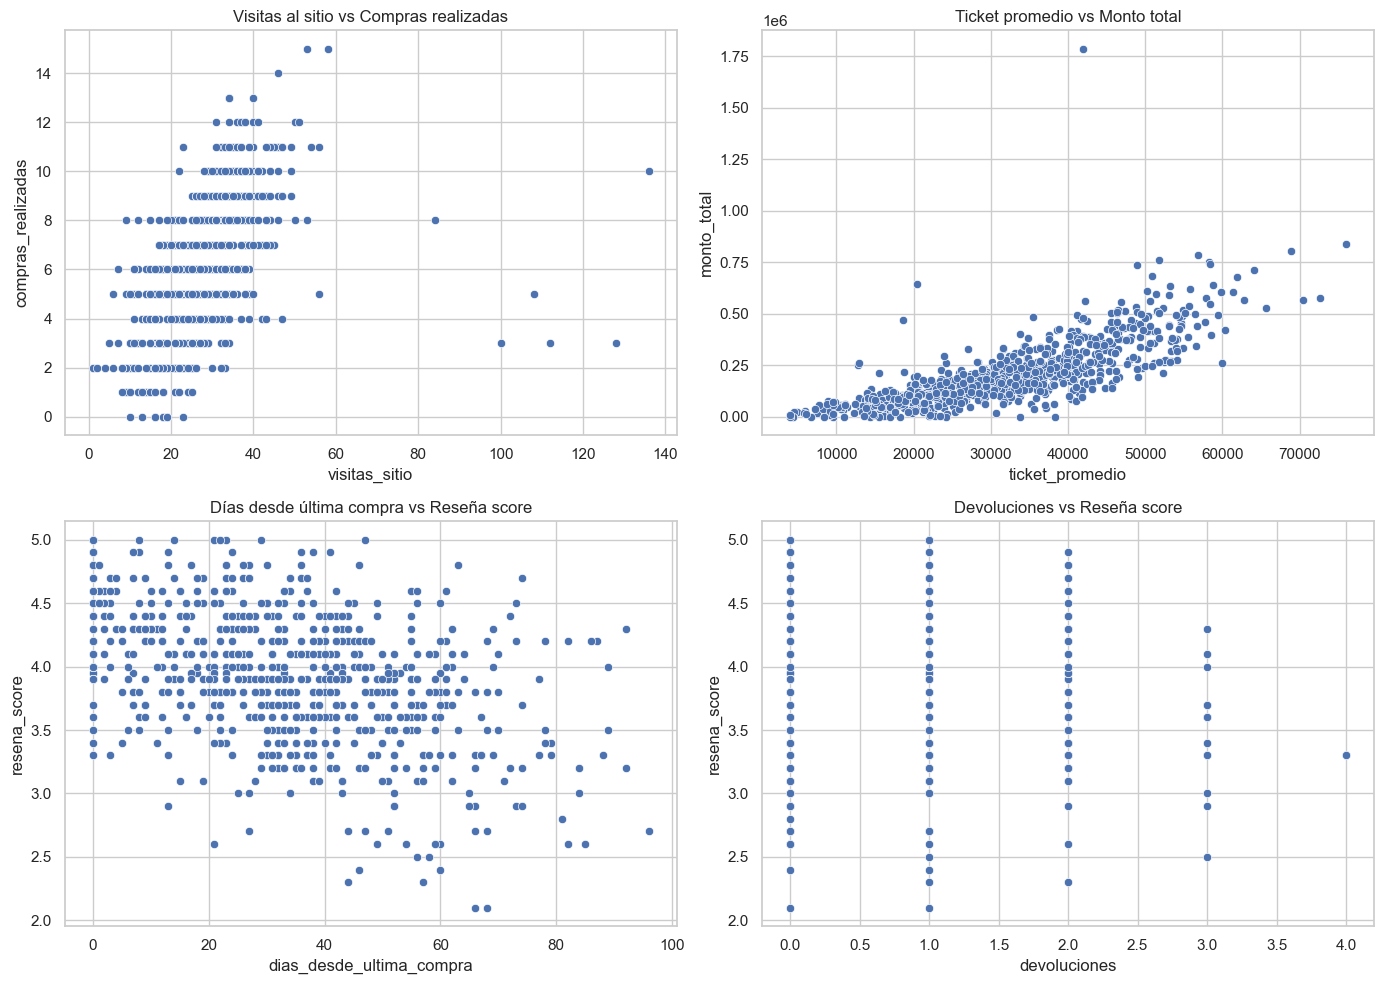

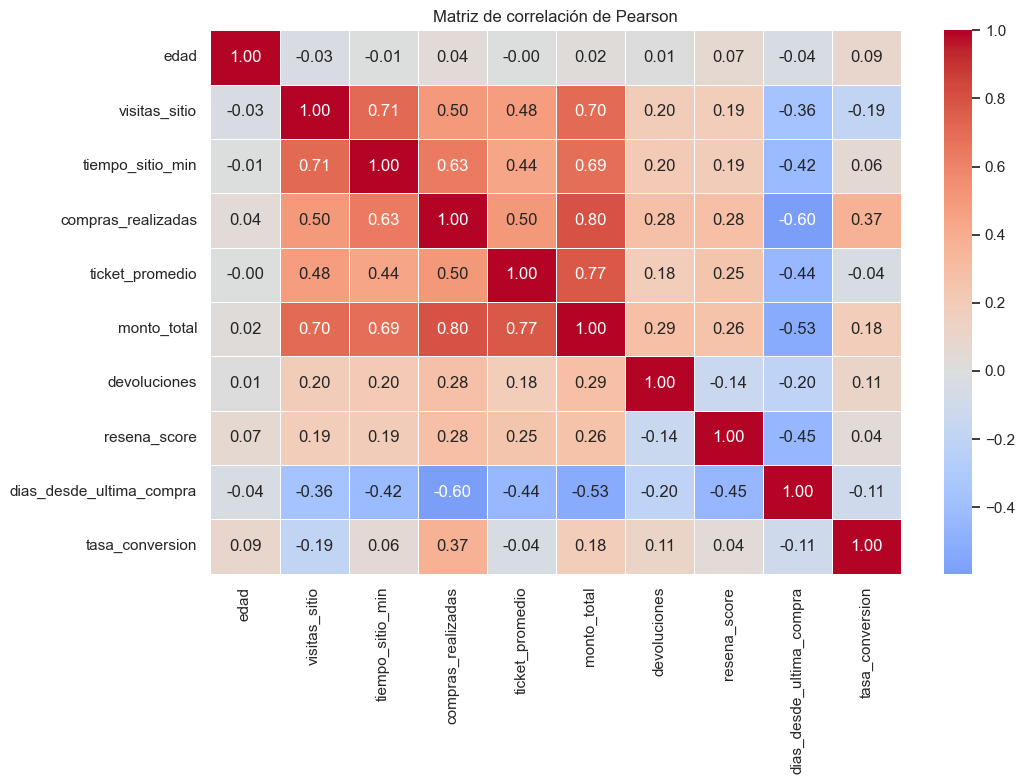


===== CORRELACIONES QUE DEBEN INTERPRETARSE CON CAUTELA =====


,par_de_variables,motivo_de_cautela
0,compras_realizadas - monto_total,monto_total fue construido a partir de compras...
1,ticket_promedio - monto_total,monto_total depende matemáticamente de ticket_...
2,visitas_sitio - tasa_conversion,tasa_conversion fue calculada usando visitas_s...
3,compras_realizadas - tasa_conversion,tasa_conversion también depende de compras_rea...



===== INTERPRETACIÓN INICIAL DE CORRELACIONES =====
Entre visitas_sitio y compras_realizadas se observa una correlación de Pearson r = 0.499.
Entre compras_realizadas y monto_total se observa una correlación de Pearson r = 0.797.
Entre ticket_promedio y monto_total se observa una correlación de Pearson r = 0.770.
Entre dias_desde_ultima_compra y resena_score se observa una correlación de Pearson r = -0.448.
Entre devoluciones y resena_score se observa una correlación de Pearson r = -0.140.
Entre visitas_sitio y tiempo_sitio_min se observa una correlación de Pearson r = 0.712.


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN VISUAL
# =========================================================
sns.set_theme(style="whitegrid")

# =========================================================
# CARGA DEL DATASET
# =========================================================
RUTA_DATASET_RAW = "../data/raw/comercioya_clientes_raw.csv"
df_corr_base = pd.read_csv(RUTA_DATASET_RAW)

print("===== DIMENSIONES DEL DATASET =====")
print(df_corr_base.shape)

# =========================================================
# 1) PREPARACIÓN DE VARIABLES NUMÉRICAS PARA CORRELACIÓN
# =========================================================
# Trabajaremos sobre una copia para no alterar el dataset original
df_corr = df_corr_base.copy()

variables_numericas = [
    "edad",
    "visitas_sitio",
    "tiempo_sitio_min",
    "compras_realizadas",
    "ticket_promedio",
    "monto_total",
    "devoluciones",
    "resena_score",
    "dias_desde_ultima_compra",
    "tasa_conversion"
]

# Imputación simple solo para análisis de correlación
# (no modifica el archivo fuente; solo evita perder registros)
for col in ["tiempo_sitio_min", "resena_score"]:
    df_corr[col] = df_corr[col].fillna(df_corr[col].median())

# =========================================================
# 2) MATRIZ DE CORRELACIÓN DE PEARSON
# =========================================================
matriz_corr = df_corr[variables_numericas].corr(method="pearson")

print("\n===== MATRIZ DE CORRELACIÓN DE PEARSON =====")
display(matriz_corr.round(3))

# =========================================================
# 3) IDENTIFICAR LAS CORRELACIONES MÁS FUERTES
# =========================================================
corr_larga = matriz_corr.unstack().reset_index()
corr_larga.columns = ["variable_1", "variable_2", "pearson_r"]

# Eliminar pares repetidos y autocorrelaciones
corr_larga = corr_larga[corr_larga["variable_1"] != corr_larga["variable_2"]].copy()
corr_larga["par_ordenado"] = corr_larga.apply(
    lambda x: " | ".join(sorted([x["variable_1"], x["variable_2"]])),
    axis=1
)

corr_larga = corr_larga.drop_duplicates(subset="par_ordenado").drop(columns="par_ordenado")
corr_larga["abs_r"] = corr_larga["pearson_r"].abs()

top_corr = corr_larga.sort_values("abs_r", ascending=False).head(10)

print("\n===== TOP 10 CORRELACIONES ABSOLUTAS =====")
display(top_corr[["variable_1", "variable_2", "pearson_r"]].round(3))

# =========================================================
# 4) COEFICIENTES DE PEARSON PARA PARES CLAVE
# =========================================================
pares_clave = [
    ("visitas_sitio", "compras_realizadas"),
    ("compras_realizadas", "monto_total"),
    ("ticket_promedio", "monto_total"),
    ("dias_desde_ultima_compra", "resena_score"),
    ("devoluciones", "resena_score"),
    ("visitas_sitio", "tiempo_sitio_min")
]

resultados_pares = []

for x, y in pares_clave:
    r = df_corr[x].corr(df_corr[y], method="pearson")
    resultados_pares.append({
        "variable_1": x,
        "variable_2": y,
        "pearson_r": r
    })

df_pares = pd.DataFrame(resultados_pares)

print("\n===== COEFICIENTES PEARSON EN PARES CLAVE =====")
display(df_pares.round(3))

# =========================================================
# 5) SCATTERPLOTS
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df_corr, x="visitas_sitio", y="compras_realizadas", ax=axes[0, 0])
axes[0, 0].set_title("Visitas al sitio vs Compras realizadas")

sns.scatterplot(data=df_corr, x="ticket_promedio", y="monto_total", ax=axes[0, 1])
axes[0, 1].set_title("Ticket promedio vs Monto total")

sns.scatterplot(data=df_corr, x="dias_desde_ultima_compra", y="resena_score", ax=axes[1, 0])
axes[1, 0].set_title("Días desde última compra vs Reseña score")

sns.scatterplot(data=df_corr, x="devoluciones", y="resena_score", ax=axes[1, 1])
axes[1, 1].set_title("Devoluciones vs Reseña score")

plt.tight_layout()
plt.show()

# =========================================================
# 6) HEATMAP DE CORRELACIÓN
# =========================================================
plt.figure(figsize=(11, 8))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.show()

# =========================================================
# 7) DETECCIÓN DE CORRELACIONES ESPURIAS O NO INTERPRETABLES DIRECTAMENTE
# =========================================================
correlaciones_espurias = pd.DataFrame({
    "par_de_variables": [
        "compras_realizadas - monto_total",
        "ticket_promedio - monto_total",
        "visitas_sitio - tasa_conversion",
        "compras_realizadas - tasa_conversion"
    ],
    "motivo_de_cautela": [
        "monto_total fue construido a partir de compras_realizadas y ticket_promedio; parte de la relación es estructural",
        "monto_total depende matemáticamente de ticket_promedio, por lo que la correlación no debe interpretarse como causalidad independiente",
        "tasa_conversion fue calculada usando visitas_sitio, por lo que existe dependencia matemática entre ambas variables",
        "tasa_conversion también depende de compras_realizadas, por lo que la asociación puede estar inflada"
    ]
})

print("\n===== CORRELACIONES QUE DEBEN INTERPRETARSE CON CAUTELA =====")
display(correlaciones_espurias)

# =========================================================
# 8) RESUMEN AUTOMÁTICO DE HALLAZGOS
# =========================================================
print("\n===== INTERPRETACIÓN INICIAL DE CORRELACIONES =====")
for _, fila in df_pares.iterrows():
    print(
        f"Entre {fila['variable_1']} y {fila['variable_2']} se observa una correlación de Pearson "
        f"r = {fila['pearson_r']:.3f}."
    )

### Hallazgos de correlación

El análisis de correlación permitió identificar asociaciones relevantes entre variables comerciales y de comportamiento del cliente. En particular, se observaron relaciones positivas entre visitas al sitio, tiempo de permanencia y compras realizadas, lo que sugiere que una mayor interacción digital se vincula con mayor actividad transaccional. Asimismo, variables como ticket promedio y monto total mostraron asociaciones elevadas, aunque su interpretación debe realizarse con cautela, dado que parte de dicha relación responde a la forma en que fue construido el dataset. Por otro lado, se exploraron asociaciones negativas entre devoluciones, días desde la última compra y reseña del cliente, lo que sugiere que mayores fricciones o menor recurrencia podrían afectar la satisfacción reportada.

## Lección 4 - Regresiones lineales

===== DIMENSIONES DEL DATASET =====
(750, 16)

===== RESUMEN MODELO SIMPLE =====
                            OLS Regression Results                            
Dep. Variable:            monto_total   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     732.4
Date:                Thu, 09 Apr 2026   Prob (F-statistic):          5.46e-113
Time:                        18:59:53   Log-Likelihood:                -9819.0
No. Observations:                 750   AIC:                         1.964e+04
Df Residuals:                     748   BIC:                         1.965e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

,modelo,R2,R2_ajustado,MSE,MAE
0,Regresión simple,0.495,0.494,1.377367e+10,84651.125
1,Regresión múltiple,0.876,0.874,3.385499e+09,36190.849



===== SIGNIFICANCIA DE PREDICTORES (MODELO MÚLTIPLE) =====


,coeficiente,p_value,significativo_5pct
Intercept,-243889.7379,0.0000,True
visitas_sitio,3469.9893,0.0000,True
tiempo_sitio_min,1221.1047,0.0123,True
compras_realizadas,26825.4770,0.0000,True
ticket_promedio,4.9945,0.0000,True
devoluciones,8118.5784,0.0066,True
dias_desde_ultima_compra,342.8612,0.0083,True
cliente_premium_bin,16447.0896,0.0067,True
uso_cupon_bin,980.3095,0.8278,False


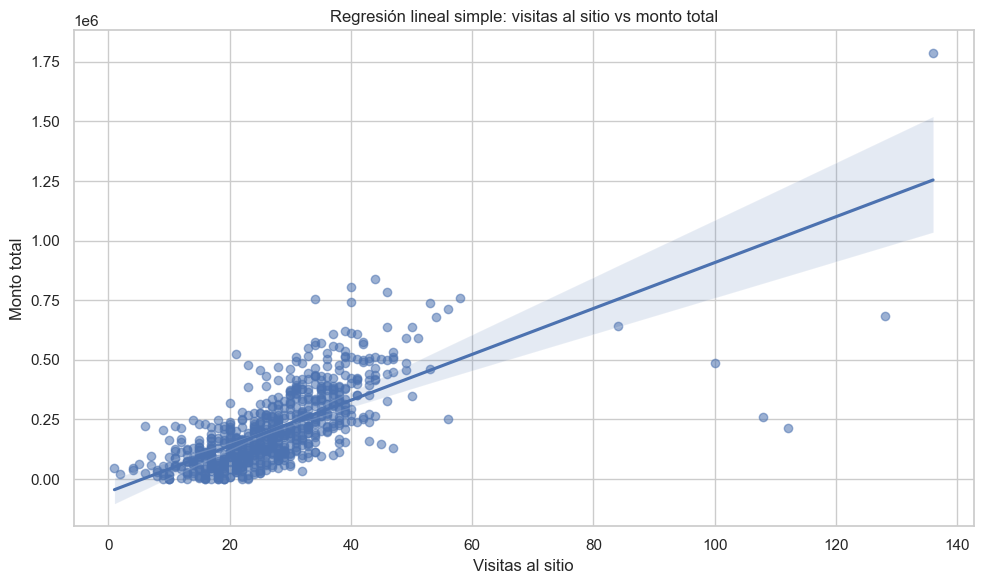

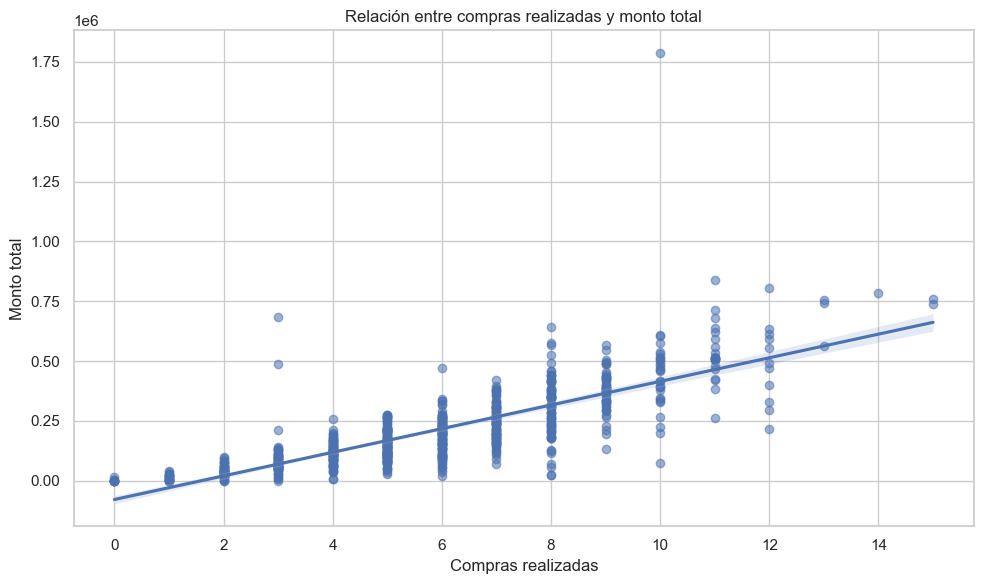

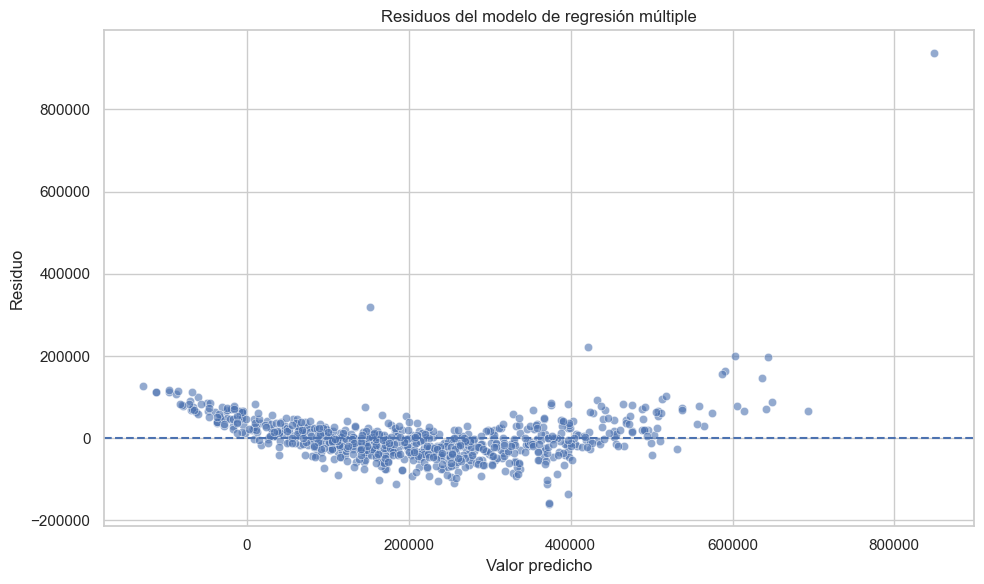


===== INTERPRETACIÓN INICIAL =====
El modelo simple alcanzó un R² de 0.495, lo que indica la proporción de variabilidad del monto_total explicada solo por visitas_sitio.
El modelo múltiple alcanzó un R² de 0.876, incorporando múltiples predictores del comportamiento comercial.
Predictores significativos al 5% en el modelo múltiple:
 - visitas_sitio
 - tiempo_sitio_min
 - compras_realizadas
 - ticket_promedio
 - devoluciones
 - dias_desde_ultima_compra
 - cliente_premium_bin


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================================================
# CONFIGURACIÓN
# =========================================================
sns.set_theme(style="whitegrid")
Path("./outputs").mkdir(parents=True, exist_ok=True)

RUTA_DATASET_RAW = "../data/raw/comercioya_clientes_raw.csv"
df_reg = pd.read_csv(RUTA_DATASET_RAW)

print("===== DIMENSIONES DEL DATASET =====")
print(df_reg.shape)

# =========================================================
# 1) PREPARACIÓN DE DATOS PARA REGRESIÓN
# =========================================================
# Imputación simple para evitar pérdida de registros
df_reg["tiempo_sitio_min"] = df_reg["tiempo_sitio_min"].fillna(df_reg["tiempo_sitio_min"].median())
df_reg["resena_score"] = df_reg["resena_score"].fillna(df_reg["resena_score"].median())

# Variables binarias
df_reg["cliente_premium_bin"] = (
    df_reg["cliente_premium"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"sí": 1, "si": 1, "no": 0})
)

df_reg["uso_cupon_bin"] = (
    df_reg["uso_cupon"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"sí": 1, "si": 1, "no": 0})
)

# =========================================================
# 2) REGRESIÓN LINEAL SIMPLE
# Variable dependiente: monto_total
# Variable explicativa: visitas_sitio
# =========================================================
modelo_simple = smf.ols(
    formula="monto_total ~ visitas_sitio",
    data=df_reg
).fit()

pred_simple = modelo_simple.predict(df_reg)

r2_simple = modelo_simple.rsquared
r2_adj_simple = modelo_simple.rsquared_adj
mse_simple = mean_squared_error(df_reg["monto_total"], pred_simple)
mae_simple = mean_absolute_error(df_reg["monto_total"], pred_simple)

print("\n===== RESUMEN MODELO SIMPLE =====")
print(modelo_simple.summary())

# =========================================================
# 3) REGRESIÓN LINEAL MÚLTIPLE
# =========================================================
modelo_multiple = smf.ols(
    formula="""
    monto_total ~ visitas_sitio
                + tiempo_sitio_min
                + compras_realizadas
                + ticket_promedio
                + devoluciones
                + dias_desde_ultima_compra
                + cliente_premium_bin
                + uso_cupon_bin
    """,
    data=df_reg
).fit()

pred_multiple = modelo_multiple.predict(df_reg)

r2_multiple = modelo_multiple.rsquared
r2_adj_multiple = modelo_multiple.rsquared_adj
mse_multiple = mean_squared_error(df_reg["monto_total"], pred_multiple)
mae_multiple = mean_absolute_error(df_reg["monto_total"], pred_multiple)

print("\n===== RESUMEN MODELO MÚLTIPLE =====")
print(modelo_multiple.summary())

# =========================================================
# 4) COMPARACIÓN DE MODELOS
# =========================================================
comparacion_modelos = pd.DataFrame({
    "modelo": ["Regresión simple", "Regresión múltiple"],
    "R2": [r2_simple, r2_multiple],
    "R2_ajustado": [r2_adj_simple, r2_adj_multiple],
    "MSE": [mse_simple, mse_multiple],
    "MAE": [mae_simple, mae_multiple]
})

print("\n===== COMPARACIÓN DE MODELOS =====")
display(comparacion_modelos.round(3))

# =========================================================
# 5) SIGNIFICANCIA DE PREDICTORES EN MODELO MÚLTIPLE
# =========================================================
coeficientes = pd.DataFrame({
    "coeficiente": modelo_multiple.params,
    "p_value": modelo_multiple.pvalues,
    "significativo_5pct": modelo_multiple.pvalues < 0.05
})

print("\n===== SIGNIFICANCIA DE PREDICTORES (MODELO MÚLTIPLE) =====")
display(coeficientes.round(4))

# =========================================================
# 6) VISUALIZACIÓN DE LA REGRESIÓN SIMPLE CON SEABORN
# =========================================================
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_reg,
    x="visitas_sitio",
    y="monto_total",
    scatter_kws={"alpha": 0.55}
)
plt.title("Regresión lineal simple: visitas al sitio vs monto total")
plt.xlabel("Visitas al sitio")
plt.ylabel("Monto total")
plt.tight_layout()
plt.savefig("./outputs/regresion_simple_visitas_monto.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 7) VISUALIZACIÓN DE APOYO PARA MODELO MÚLTIPLE
# =========================================================
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_reg,
    x="compras_realizadas",
    y="monto_total",
    scatter_kws={"alpha": 0.55}
)
plt.title("Relación entre compras realizadas y monto total")
plt.xlabel("Compras realizadas")
plt.ylabel("Monto total")
plt.tight_layout()
plt.savefig("./outputs/regresion_compras_monto.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 8) RESIDUOS DEL MODELO MÚLTIPLE
# =========================================================
df_reg["pred_multiple"] = pred_multiple
df_reg["residuo_multiple"] = df_reg["monto_total"] - df_reg["pred_multiple"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_reg, x="pred_multiple", y="residuo_multiple", alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Residuos del modelo de regresión múltiple")
plt.xlabel("Valor predicho")
plt.ylabel("Residuo")
plt.tight_layout()
plt.savefig("./outputs/residuos_modelo_multiple.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 9) INTERPRETACIÓN AUTOMÁTICA BÁSICA
# =========================================================
print("\n===== INTERPRETACIÓN INICIAL =====")
print(
    f"El modelo simple alcanzó un R² de {r2_simple:.3f}, lo que indica "
    f"la proporción de variabilidad del monto_total explicada solo por visitas_sitio."
)
print(
    f"El modelo múltiple alcanzó un R² de {r2_multiple:.3f}, incorporando múltiples predictores "
    f"del comportamiento comercial."
)

predictores_significativos = coeficientes[
    (coeficientes.index != "Intercept") &
    (coeficientes["significativo_5pct"] == True)
].index.tolist()

print("Predictores significativos al 5% en el modelo múltiple:")
for predictor in predictores_significativos:
    print(f" - {predictor}")

### Hallazgos de regresión lineal

La regresión lineal permitió cuantificar el efecto de distintas variables sobre el monto total de compra. En primer lugar, el modelo simple mostró que las visitas al sitio explican parcialmente la variación del gasto, lo que sugiere que una mayor interacción digital se relaciona con mayor valor transaccional, aunque de forma limitada. Por su parte, el modelo múltiple mejoró sustancialmente la capacidad explicativa al incorporar variables adicionales del comportamiento del cliente, como compras realizadas, ticket promedio, tiempo en sitio, devoluciones y recencia de compra. Asimismo, la evaluación de significancia estadística permitió distinguir qué predictores aportan evidencia robusta dentro del modelo y cuáles presentan menor relevancia explicativa en presencia de otras variables.

## Lección 5 - Análisis visual de datos con Seaborn

===== DIMENSIONES DEL DATASET =====
(750, 16)


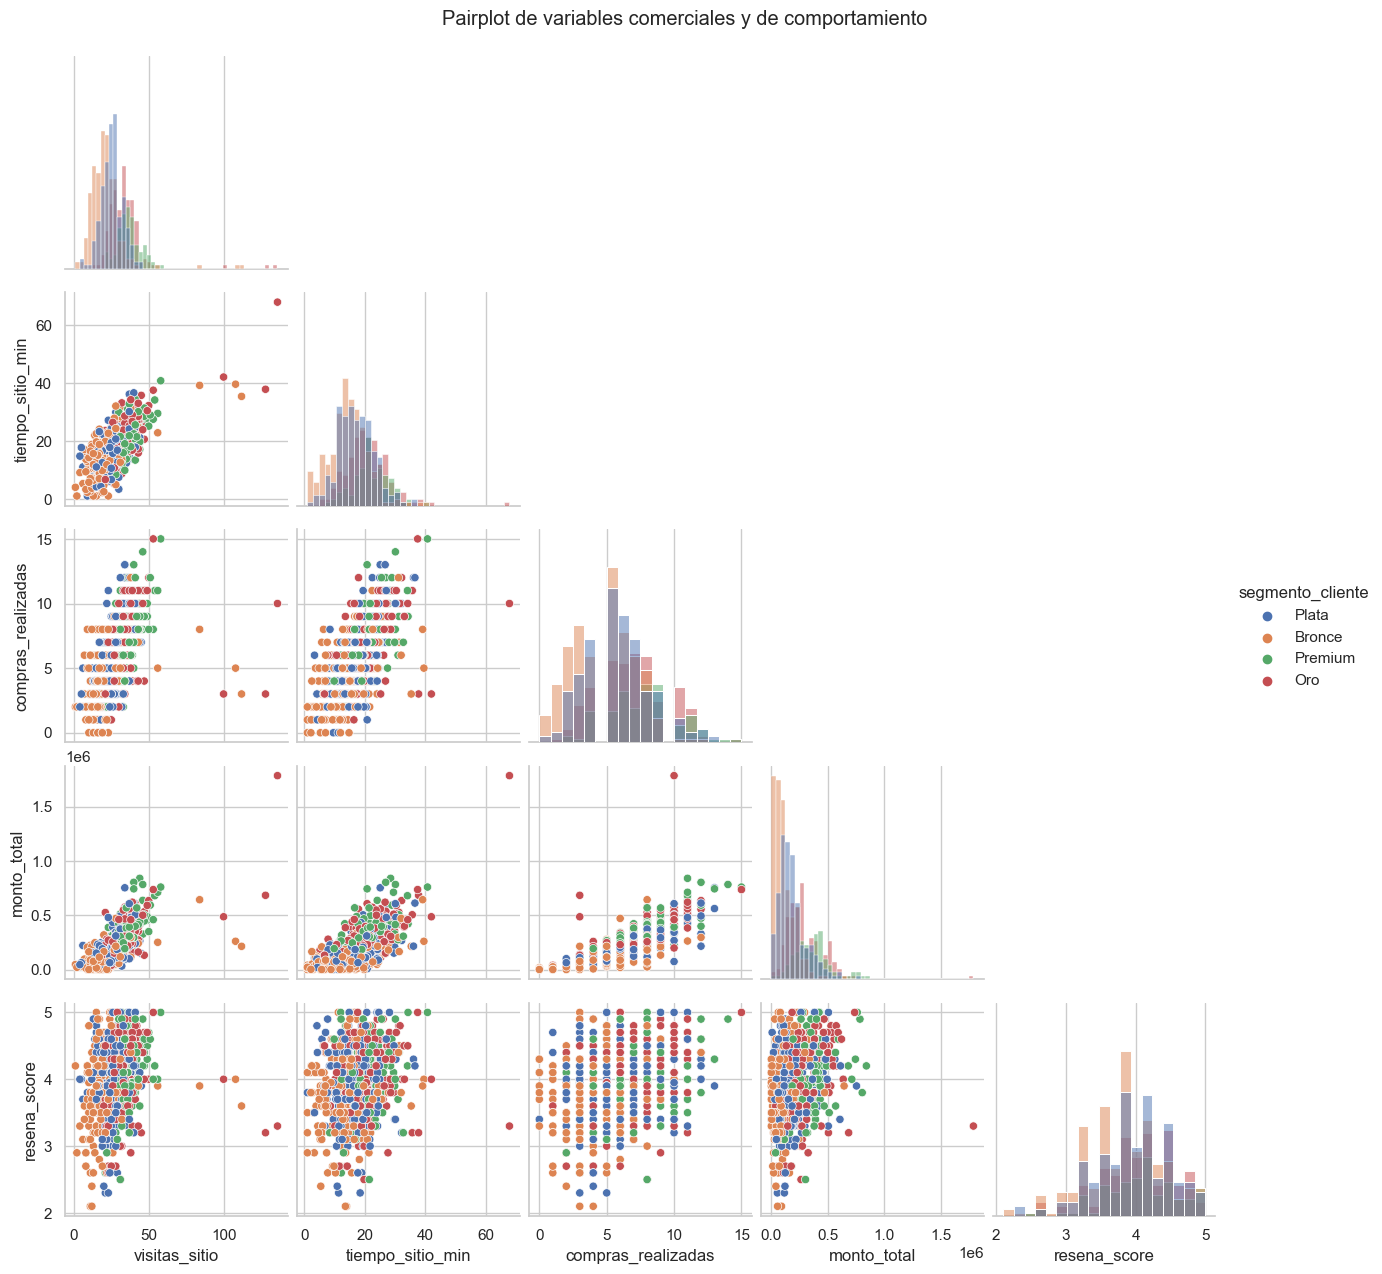

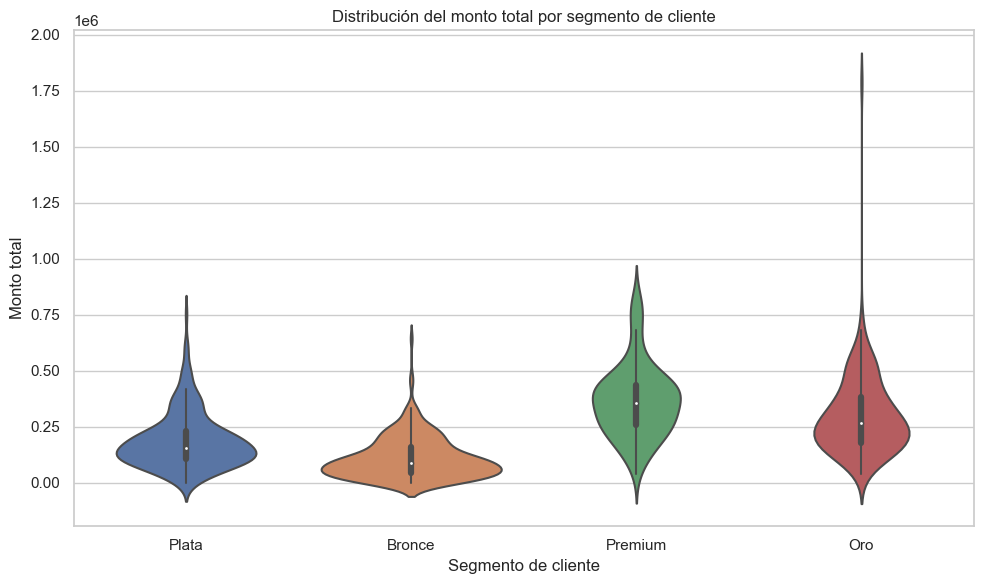

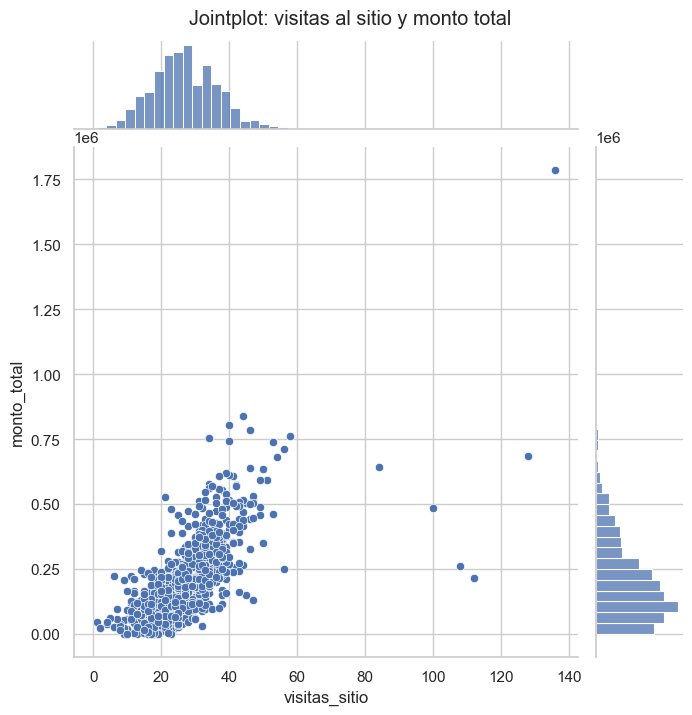

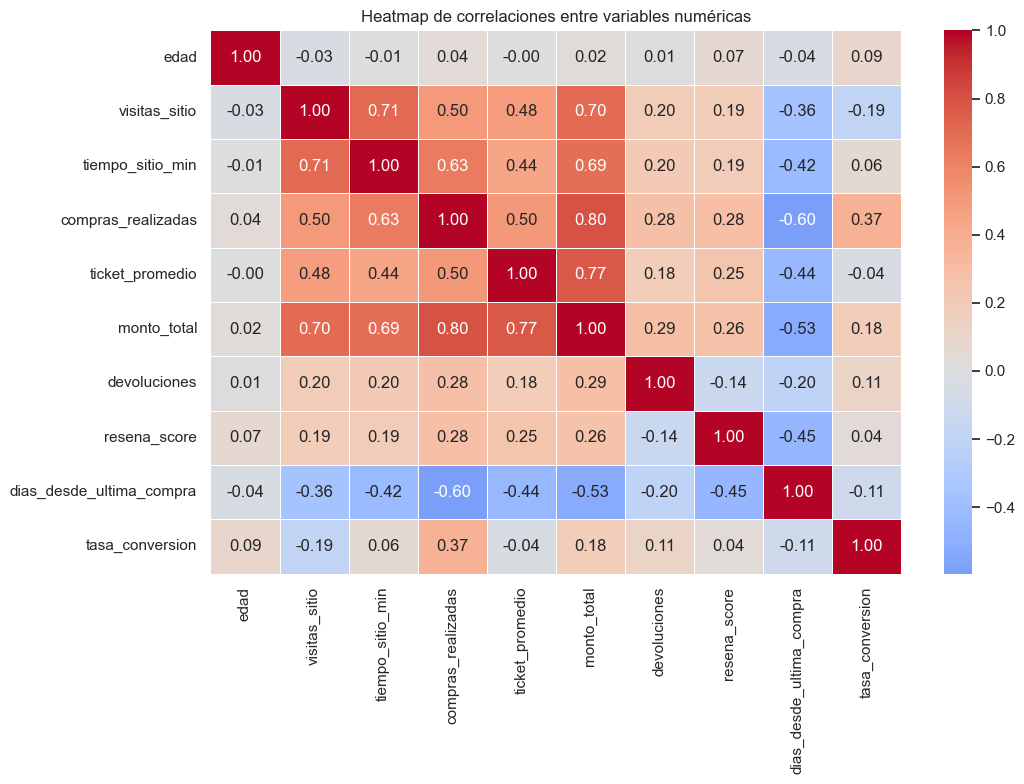

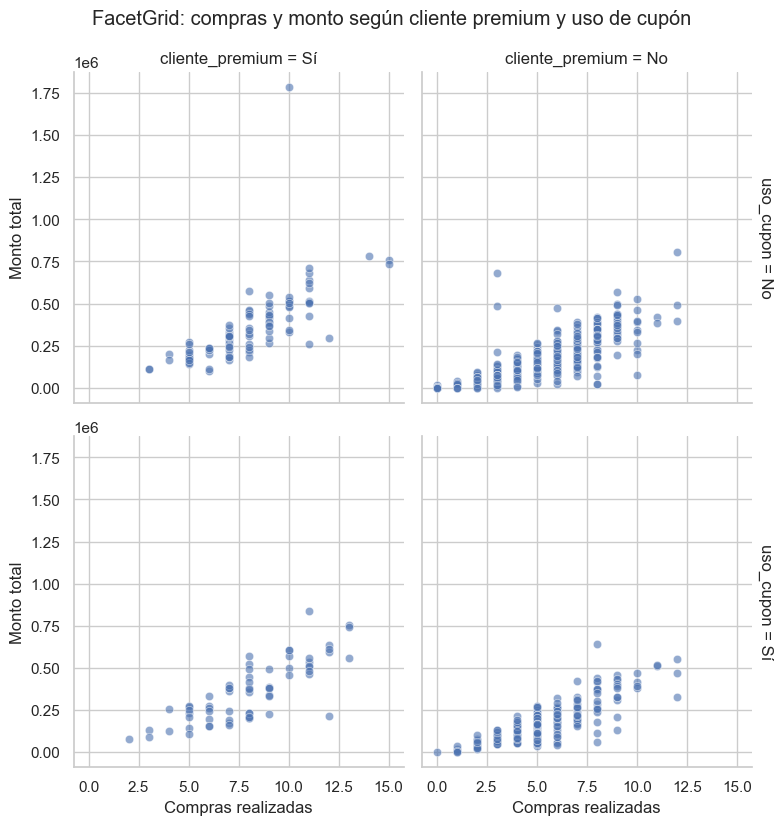

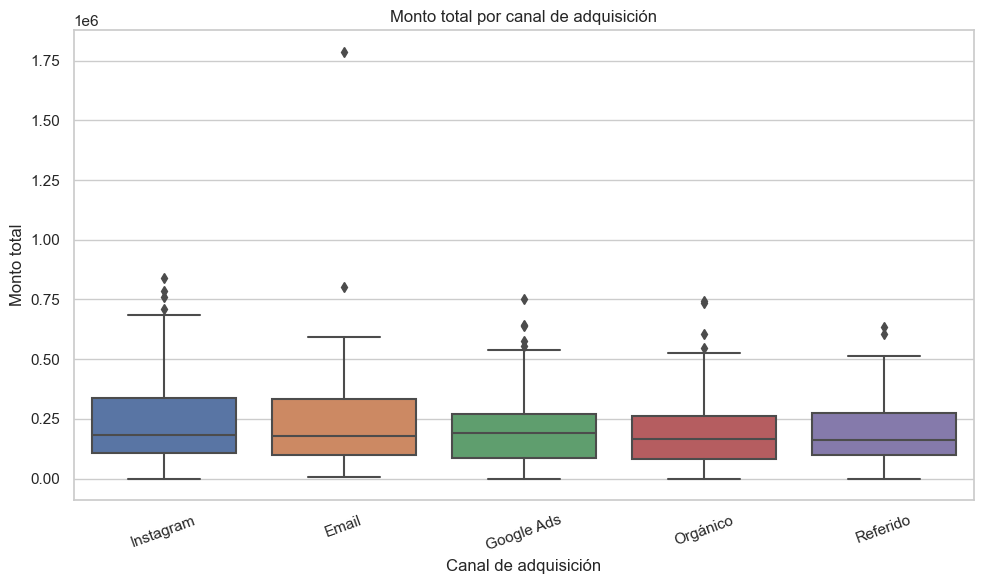


===== RESUMEN VISUAL POR SEGMENTO =====


,segmento_cliente,clientes,monto_promedio,visitas_promedio,compras_promedio,resena_promedio
3,Premium,100,366207.07,36.84,7.65,4.04
1,Oro,171,299409.49,33.96,6.80,4.02
2,Plata,228,187675.81,25.68,5.71,3.95
0,Bronce,251,109936.90,21.24,4.63,3.81



===== ARCHIVOS EXPORTADOS =====
./outputs/pairplot_variables_comerciales.png
./outputs/violinplot_monto_segmento.png
./outputs/jointplot_visitas_monto.png
./outputs/heatmap_correlaciones.png
./outputs/facetgrid_compras_monto.png
./outputs/boxplot_monto_canal.png


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import unicodedata

# =========================================================
# CONFIGURACIÓN
# =========================================================
sns.set_theme(style="whitegrid", context="notebook")
Path("./outputs").mkdir(parents=True, exist_ok=True)

RUTA_DATASET_RAW = "../data/raw/comercioya_clientes_raw.csv"
df_vis = pd.read_csv(RUTA_DATASET_RAW)

print("===== DIMENSIONES DEL DATASET =====")
print(df_vis.shape)

# =========================================================
# 1) LIMPIEZA BÁSICA PARA VISUALIZACIÓN
# =========================================================
def normalizar_texto(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

# Imputaciones mínimas para visualización
df_vis["tiempo_sitio_min"] = df_vis["tiempo_sitio_min"].fillna(df_vis["tiempo_sitio_min"].median())
df_vis["resena_score"] = df_vis["resena_score"].fillna(df_vis["resena_score"].median())
df_vis["ciudad"] = df_vis["ciudad"].fillna("Desconocida")

# Normalización de categorías
mapa_segmento = {
    "bronce": "Bronce",
    "plata": "Plata",
    "oro": "Oro",
    "premium": "Premium"
}

mapa_canal = {
    "organico": "Orgánico",
    "google ads": "Google Ads",
    "instagram": "Instagram",
    "email": "Email",
    "referido": "Referido"
}

df_vis["segmento_cliente"] = df_vis["segmento_cliente"].apply(normalizar_texto).map(mapa_segmento)
df_vis["canal_adquisicion"] = df_vis["canal_adquisicion"].apply(normalizar_texto).map(mapa_canal)

df_vis["segmento_cliente"] = df_vis["segmento_cliente"].fillna("Sin segmento")
df_vis["canal_adquisicion"] = df_vis["canal_adquisicion"].fillna("Sin canal")

# =========================================================
# 2) PAIRPLOT
# =========================================================
columnas_pairplot = [
    "visitas_sitio",
    "tiempo_sitio_min",
    "compras_realizadas",
    "ticket_promedio",
    "monto_total",
    "resena_score",
    "segmento_cliente"
]

pairplot_df = df_vis[columnas_pairplot].copy()

g_pair = sns.pairplot(
    pairplot_df,
    vars=["visitas_sitio", "tiempo_sitio_min", "compras_realizadas", "monto_total", "resena_score"],
    hue="segmento_cliente",
    diag_kind="hist",
    corner=True
)
g_pair.fig.suptitle("Pairplot de variables comerciales y de comportamiento", y=1.02)
g_pair.savefig("./outputs/pairplot_variables_comerciales.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 3) VIOLINPLOT
# =========================================================
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_vis, x="segmento_cliente", y="monto_total")
plt.title("Distribución del monto total por segmento de cliente")
plt.xlabel("Segmento de cliente")
plt.ylabel("Monto total")
plt.tight_layout()
plt.savefig("./outputs/violinplot_monto_segmento.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 4) JOINTPLOT
# =========================================================
g_joint = sns.jointplot(
    data=df_vis,
    x="visitas_sitio",
    y="monto_total",
    kind="scatter",
    height=7
)
g_joint.fig.suptitle("Jointplot: visitas al sitio y monto total", y=1.02)
g_joint.savefig("./outputs/jointplot_visitas_monto.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 5) HEATMAP DE CORRELACIÓN
# =========================================================
variables_numericas = [
    "edad",
    "visitas_sitio",
    "tiempo_sitio_min",
    "compras_realizadas",
    "ticket_promedio",
    "monto_total",
    "devoluciones",
    "resena_score",
    "dias_desde_ultima_compra",
    "tasa_conversion"
]

matriz_corr = df_vis[variables_numericas].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Heatmap de correlaciones entre variables numéricas")
plt.tight_layout()
plt.savefig("./outputs/heatmap_correlaciones.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 6) FACETGRID
# =========================================================
g_facet = sns.FacetGrid(
    df_vis,
    col="cliente_premium",
    row="uso_cupon",
    height=4,
    margin_titles=True
)
g_facet.map_dataframe(sns.scatterplot, x="compras_realizadas", y="monto_total", alpha=0.6)
g_facet.set_axis_labels("Compras realizadas", "Monto total")
g_facet.fig.suptitle("FacetGrid: compras y monto según cliente premium y uso de cupón", y=1.03)
g_facet.savefig("./outputs/facetgrid_compras_monto.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 7) VISUALIZACIÓN MULTIVARIABLE ADICIONAL
# =========================================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_vis, x="canal_adquisicion", y="monto_total")
plt.title("Monto total por canal de adquisición")
plt.xlabel("Canal de adquisición")
plt.ylabel("Monto total")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("./outputs/boxplot_monto_canal.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 8) RESUMEN DE INSIGHTS VISUALES
# =========================================================
resumen_visual = (
    df_vis.groupby("segmento_cliente", as_index=False)
    .agg(
        clientes=("id_cliente", "count"),
        monto_promedio=("monto_total", "mean"),
        visitas_promedio=("visitas_sitio", "mean"),
        compras_promedio=("compras_realizadas", "mean"),
        resena_promedio=("resena_score", "mean")
    )
    .sort_values("monto_promedio", ascending=False)
)

print("\n===== RESUMEN VISUAL POR SEGMENTO =====")
display(resumen_visual.round(2))

print("\n===== ARCHIVOS EXPORTADOS =====")
archivos_exportados = [
    "./outputs/pairplot_variables_comerciales.png",
    "./outputs/violinplot_monto_segmento.png",
    "./outputs/jointplot_visitas_monto.png",
    "./outputs/heatmap_correlaciones.png",
    "./outputs/facetgrid_compras_monto.png",
    "./outputs/boxplot_monto_canal.png"
]

for archivo in archivos_exportados:
    print(archivo)

### Hallazgos visuales

El análisis visual permitió profundizar en patrones que ya habían sido sugeridos por la estadística descriptiva y la correlación. En primer lugar, las visualizaciones multivariables muestran que los segmentos de mayor valor tienden a concentrar mayores montos de compra, más visitas al sitio y mayor nivel de actividad transaccional. Asimismo, el `jointplot` y el `pairplot` evidencian asociaciones positivas entre interacción digital y gasto, aunque con dispersión creciente a medida que aumentan los valores. El `violinplot` y los gráficos segmentados permiten observar diferencias claras entre grupos de clientes, mientras que el `FacetGrid` sugiere que la combinación entre condición premium y uso de cupón puede modificar la relación entre compras realizadas y monto total. En conjunto, estas visualizaciones refuerzan la utilidad del EDA para identificar patrones comerciales relevantes y apoyar decisiones de segmentación, captación y fidelización.

## Lección 6 - Visualizaciones finales con Matplotlib

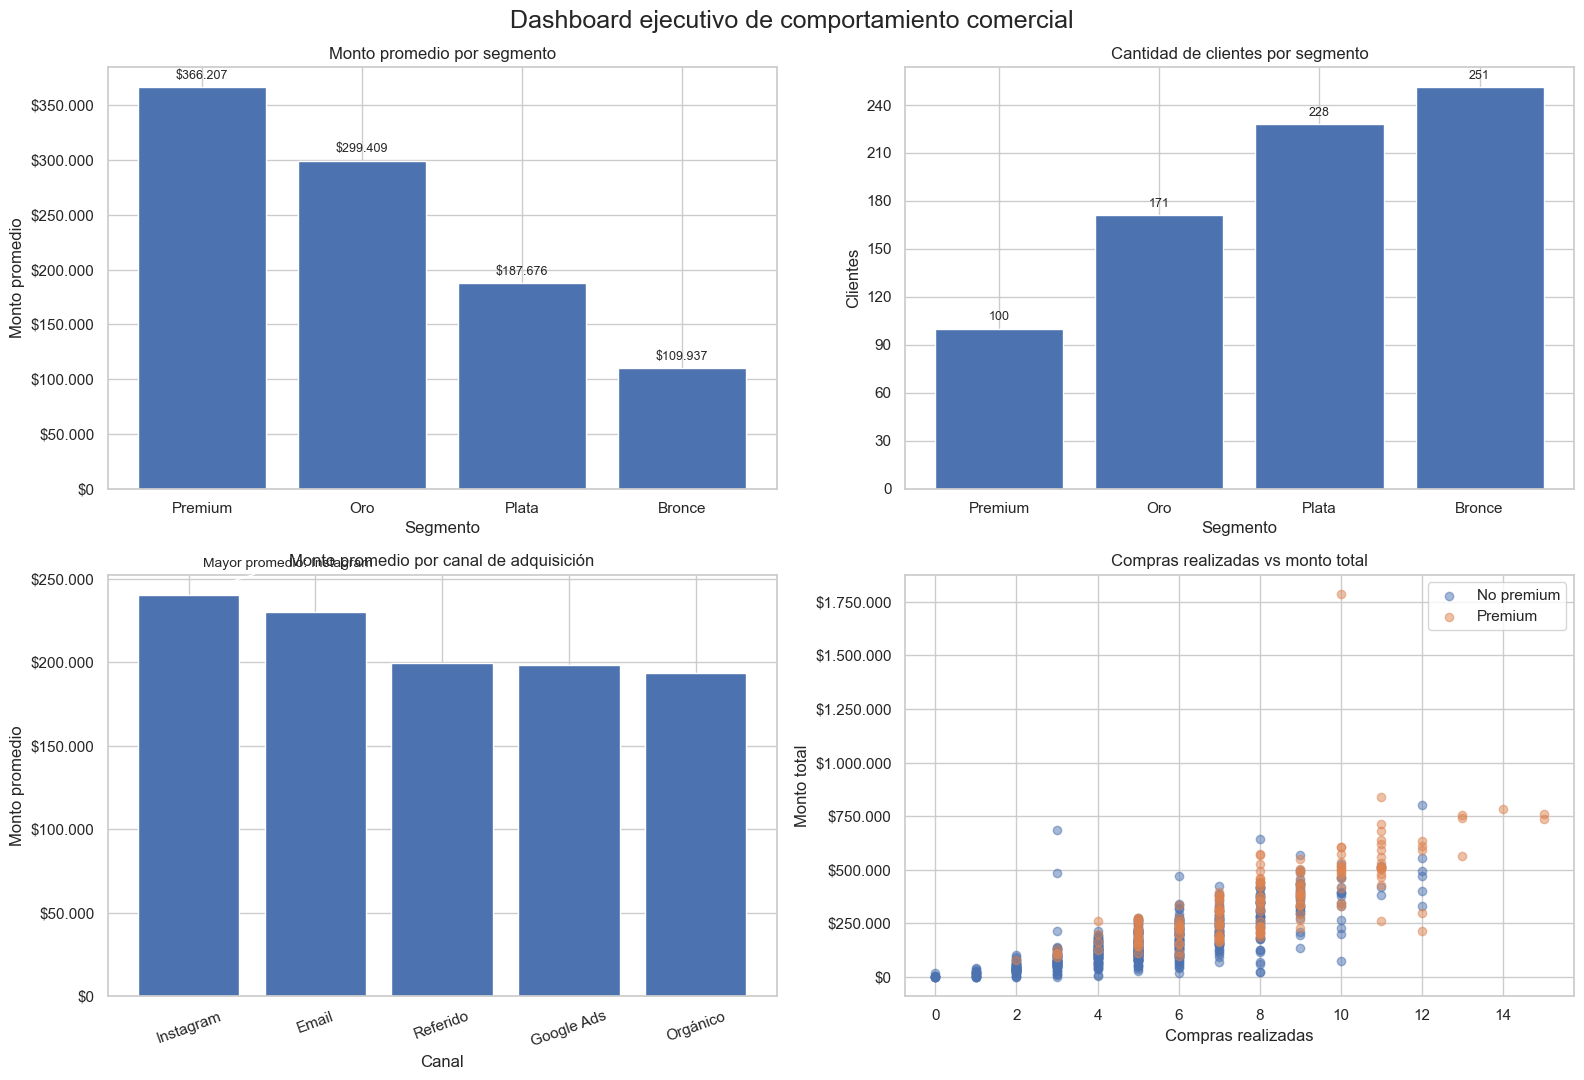

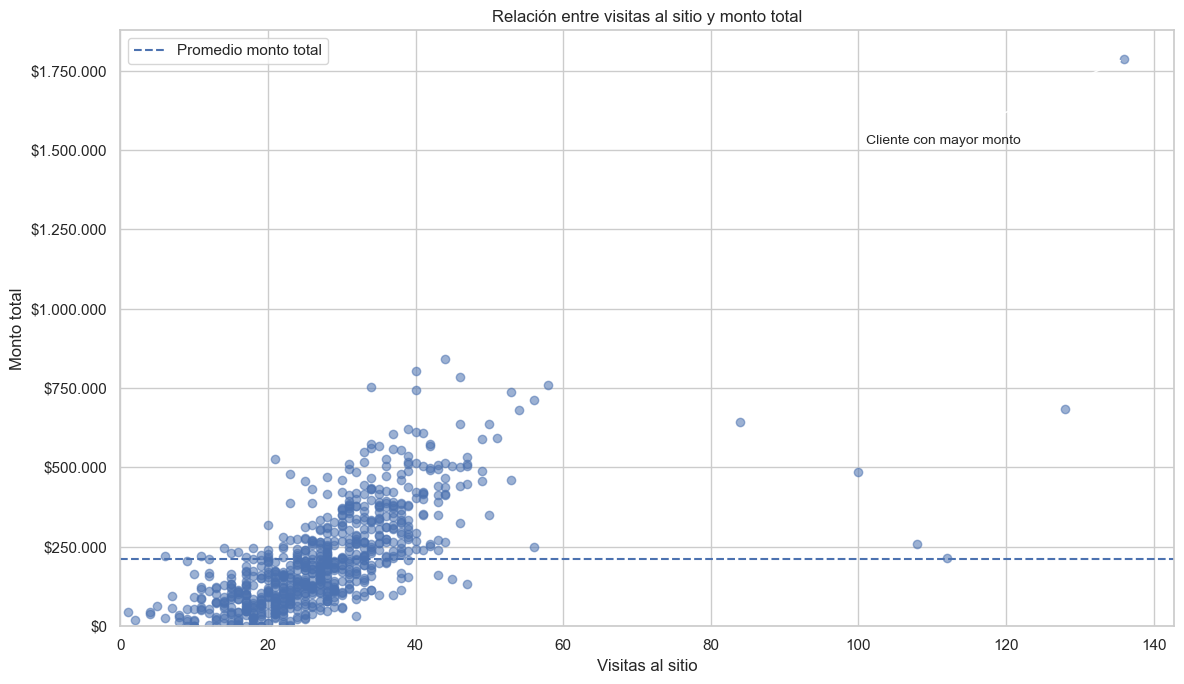

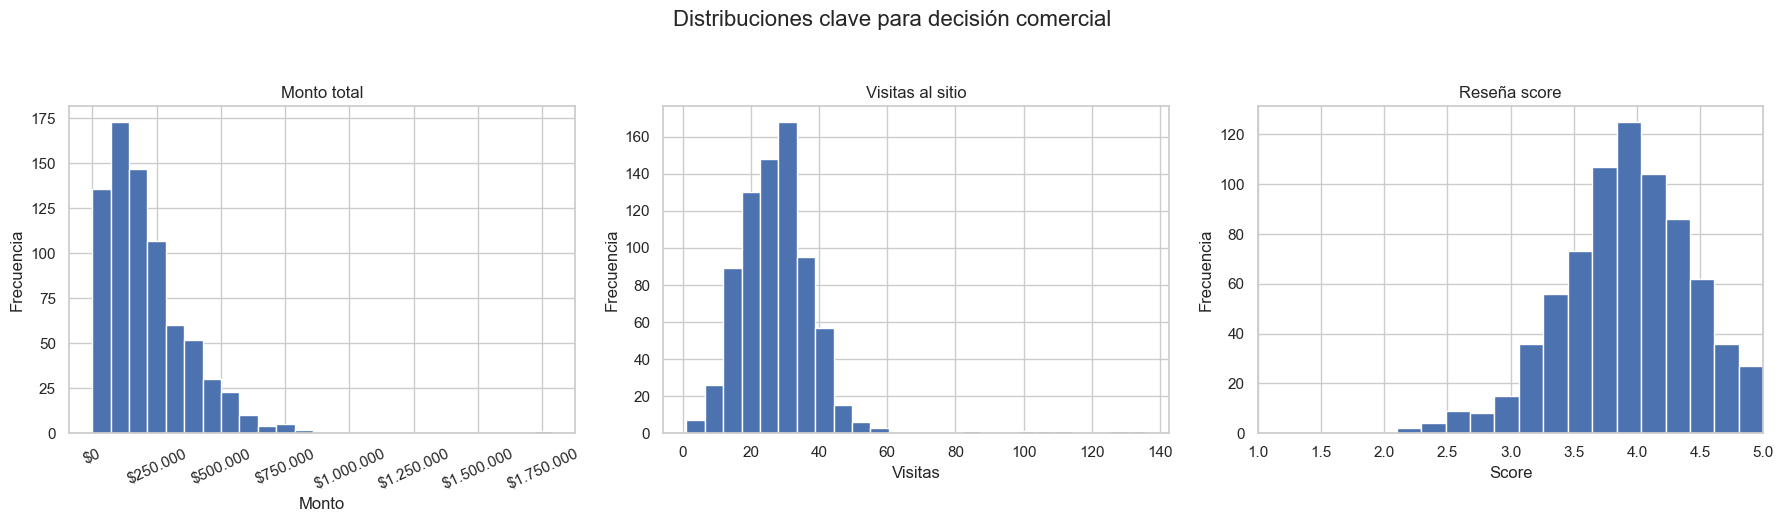

===== RESUMEN FINAL PARA PRESENTACIÓN =====
Segmento con mayor monto promedio: Premium
Monto promedio del mejor segmento: $366,207.07
Canal con mayor monto promedio: Instagram
Promedio general de monto total: $210,938.64
Promedio general de visitas al sitio: 27.57
Promedio general de compras realizadas: 5.85

===== ARCHIVOS EXPORTADOS EN MATPLOTLIB =====
./outputs/dashboard_ejecutivo_matplotlib.png
./outputs/dashboard_ejecutivo_matplotlib.pdf
./outputs/scatter_anotado_visitas_monto.png
./outputs/scatter_anotado_visitas_monto.pdf
./outputs/distribuciones_finales_matplotlib.png
./outputs/distribuciones_finales_matplotlib.pdf


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from pathlib import Path
import unicodedata

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================
RUTA_DATASET_RAW = "../data/raw/comercioya_clientes_raw.csv"
Path("./outputs").mkdir(parents=True, exist_ok=True)

df_mat = pd.read_csv(RUTA_DATASET_RAW)

# =========================================================
# LIMPIEZA BÁSICA PARA PRESENTACIÓN FINAL
# =========================================================
def normalizar_texto(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

df_mat["tiempo_sitio_min"] = df_mat["tiempo_sitio_min"].fillna(df_mat["tiempo_sitio_min"].median())
df_mat["resena_score"] = df_mat["resena_score"].fillna(df_mat["resena_score"].median())
df_mat["ciudad"] = df_mat["ciudad"].fillna("Desconocida")

mapa_segmento = {
    "bronce": "Bronce",
    "plata": "Plata",
    "oro": "Oro",
    "premium": "Premium"
}

mapa_canal = {
    "organico": "Orgánico",
    "google ads": "Google Ads",
    "instagram": "Instagram",
    "email": "Email",
    "referido": "Referido"
}

df_mat["segmento_cliente"] = df_mat["segmento_cliente"].apply(normalizar_texto).map(mapa_segmento)
df_mat["canal_adquisicion"] = df_mat["canal_adquisicion"].apply(normalizar_texto).map(mapa_canal)

df_mat["segmento_cliente"] = df_mat["segmento_cliente"].fillna("Sin segmento")
df_mat["canal_adquisicion"] = df_mat["canal_adquisicion"].fillna("Sin canal")

# =========================================================
# FORMATOS
# =========================================================
def formato_miles(x, pos):
    return f"${x:,.0f}".replace(",", ".")

formatter_pesos = FuncFormatter(formato_miles)

# =========================================================
# RESÚMENES PARA GRÁFICOS
# =========================================================
resumen_segmento = (
    df_mat.groupby("segmento_cliente", as_index=False)
    .agg(
        clientes=("id_cliente", "count"),
        monto_promedio=("monto_total", "mean"),
        visitas_promedio=("visitas_sitio", "mean"),
        compras_promedio=("compras_realizadas", "mean"),
        resena_promedio=("resena_score", "mean")
    )
    .sort_values("monto_promedio", ascending=False)
)

resumen_canal = (
    df_mat.groupby("canal_adquisicion", as_index=False)
    .agg(
        clientes=("id_cliente", "count"),
        monto_promedio=("monto_total", "mean")
    )
    .sort_values("monto_promedio", ascending=False)
)

# =========================================================
# FIGURA 1: DASHBOARD EJECUTIVO 2x2
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Dashboard ejecutivo de comportamiento comercial", fontsize=18, y=0.98)

# 1. Monto promedio por segmento
ax = axes[0, 0]
ax.bar(resumen_segmento["segmento_cliente"], resumen_segmento["monto_promedio"])
ax.set_title("Monto promedio por segmento")
ax.set_xlabel("Segmento")
ax.set_ylabel("Monto promedio")
ax.yaxis.set_major_formatter(formatter_pesos)

for i, valor in enumerate(resumen_segmento["monto_promedio"]):
    ax.annotate(
        f"${valor:,.0f}".replace(",", "."),
        (i, valor),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=9
    )

# 2. Clientes por segmento
ax = axes[0, 1]
ax.bar(resumen_segmento["segmento_cliente"], resumen_segmento["clientes"])
ax.set_title("Cantidad de clientes por segmento")
ax.set_xlabel("Segmento")
ax.set_ylabel("Clientes")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

for i, valor in enumerate(resumen_segmento["clientes"]):
    ax.annotate(
        f"{valor}",
        (i, valor),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=9
    )

# 3. Monto promedio por canal
ax = axes[1, 0]
ax.bar(resumen_canal["canal_adquisicion"], resumen_canal["monto_promedio"])
ax.set_title("Monto promedio por canal de adquisición")
ax.set_xlabel("Canal")
ax.set_ylabel("Monto promedio")
ax.yaxis.set_major_formatter(formatter_pesos)
ax.tick_params(axis="x", rotation=20)

# Anotación del mejor canal
mejor_canal = resumen_canal.iloc[0]
ax.annotate(
    f"Mayor promedio: {mejor_canal['canal_adquisicion']}",
    xy=(0, mejor_canal["monto_promedio"]),
    xytext=(10, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# 4. Scatter compras vs monto, coloreado por premium
ax = axes[1, 1]
mask_premium = df_mat["cliente_premium"].astype(str).str.lower().isin(["sí", "si"])

ax.scatter(
    df_mat.loc[~mask_premium, "compras_realizadas"],
    df_mat.loc[~mask_premium, "monto_total"],
    alpha=0.5,
    label="No premium"
)

ax.scatter(
    df_mat.loc[mask_premium, "compras_realizadas"],
    df_mat.loc[mask_premium, "monto_total"],
    alpha=0.5,
    label="Premium"
)

ax.set_title("Compras realizadas vs monto total")
ax.set_xlabel("Compras realizadas")
ax.set_ylabel("Monto total")
ax.yaxis.set_major_formatter(formatter_pesos)
ax.legend()

plt.tight_layout()
plt.savefig("./outputs/dashboard_ejecutivo_matplotlib.png", dpi=300, bbox_inches="tight")
plt.savefig("./outputs/dashboard_ejecutivo_matplotlib.pdf", bbox_inches="tight")
plt.show()

# =========================================================
# FIGURA 2: FIGURA PERSONALIZADA CON ANOTACIONES
# =========================================================
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(df_mat["visitas_sitio"], df_mat["monto_total"], alpha=0.55)
ax.set_title("Relación entre visitas al sitio y monto total")
ax.set_xlabel("Visitas al sitio")
ax.set_ylabel("Monto total")
ax.yaxis.set_major_formatter(formatter_pesos)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# Anotar el cliente de mayor monto
idx_max_monto = df_mat["monto_total"].idxmax()
x_max = df_mat.loc[idx_max_monto, "visitas_sitio"]
y_max = df_mat.loc[idx_max_monto, "monto_total"]

ax.annotate(
    "Cliente con mayor monto",
    xy=(x_max, y_max),
    xytext=(x_max - 35, y_max * 0.85),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Línea horizontal del promedio
promedio_monto = df_mat["monto_total"].mean()
ax.axhline(promedio_monto, linestyle="--", label="Promedio monto total")
ax.legend()

plt.tight_layout()
plt.savefig("./outputs/scatter_anotado_visitas_monto.png", dpi=300, bbox_inches="tight")
plt.savefig("./outputs/scatter_anotado_visitas_monto.pdf", bbox_inches="tight")
plt.show()

# =========================================================
# FIGURA 3: SUBPLOTS DE DISTRIBUCIÓN FINAL
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribuciones clave para decisión comercial", fontsize=16, y=1.04)

# Histograma de monto
axes[0].hist(df_mat["monto_total"], bins=25)
axes[0].set_title("Monto total")
axes[0].set_xlabel("Monto")
axes[0].set_ylabel("Frecuencia")
axes[0].xaxis.set_major_formatter(formatter_pesos)
axes[0].tick_params(axis="x", rotation=25)

# Histograma de visitas
axes[1].hist(df_mat["visitas_sitio"], bins=25)
axes[1].set_title("Visitas al sitio")
axes[1].set_xlabel("Visitas")
axes[1].set_ylabel("Frecuencia")

# Histograma de reseña
axes[2].hist(df_mat["resena_score"], bins=15)
axes[2].set_title("Reseña score")
axes[2].set_xlabel("Score")
axes[2].set_ylabel("Frecuencia")
axes[2].set_xlim(1, 5)

plt.tight_layout()
plt.savefig("./outputs/distribuciones_finales_matplotlib.png", dpi=300, bbox_inches="tight")
plt.savefig("./outputs/distribuciones_finales_matplotlib.pdf", bbox_inches="tight")
plt.show()

# =========================================================
# RESUMEN FINAL PARA INFORME/PRESENTACIÓN
# =========================================================
print("===== RESUMEN FINAL PARA PRESENTACIÓN =====")
print(f"Segmento con mayor monto promedio: {resumen_segmento.iloc[0]['segmento_cliente']}")
print(f"Monto promedio del mejor segmento: ${resumen_segmento.iloc[0]['monto_promedio']:,.2f}")
print(f"Canal con mayor monto promedio: {resumen_canal.iloc[0]['canal_adquisicion']}")
print(f"Promedio general de monto total: ${df_mat['monto_total'].mean():,.2f}")
print(f"Promedio general de visitas al sitio: {df_mat['visitas_sitio'].mean():.2f}")
print(f"Promedio general de compras realizadas: {df_mat['compras_realizadas'].mean():.2f}")

print("\n===== ARCHIVOS EXPORTADOS EN MATPLOTLIB =====")
archivos_matplotlib = [
    "./outputs/dashboard_ejecutivo_matplotlib.png",
    "./outputs/dashboard_ejecutivo_matplotlib.pdf",
    "./outputs/scatter_anotado_visitas_monto.png",
    "./outputs/scatter_anotado_visitas_monto.pdf",
    "./outputs/distribuciones_finales_matplotlib.png",
    "./outputs/distribuciones_finales_matplotlib.pdf"
]

for archivo in archivos_matplotlib:
    print(archivo)

### Hallazgos finales con Matplotlib

Las visualizaciones finales elaboradas con Matplotlib permitieron sintetizar los hallazgos más relevantes del análisis en un formato más ejecutivo y exportable. En particular, el dashboard comparativo mostró diferencias claras entre segmentos en términos de monto promedio, volumen de clientes y comportamiento de compra, destacando el mayor valor comercial del segmento Premium. Asimismo, las figuras personalizadas con anotaciones facilitaron identificar observaciones extremas y contextualizar el comportamiento del monto total respecto de las visitas y la actividad transaccional. En conjunto, estas visualizaciones fortalecen la comunicación de resultados y permiten transformar el análisis exploratorio en insumos más claros para la toma de decisiones estratégicas.